# Shape-conditioned energy model: prediction quality and spatial allocation

Restore models trained on measured-organoid-mean/SD normalized targets, without retraining. The question is **whether exclusive fate patterns predict the spatial allocation of curvature, given each organoid's measured curvature level and spread**. This is conditional reconstruction, not fate-only prediction of shape, and does not causally factor out developmental history.

Compare center identity, all-to-all one-hop presence with accommodation, and a plain depth-1 GIN. A matched mean-subtraction-only energy model separates the benefit of rescaling from knowing the mean. The old presence model is shown both unchanged and with its graph mean replaced by the measured mean. Gamma and GIN epochs were selected on inner-training organoids only; outer and spherical cohorts are evaluations.

Eight figures show accommodation profiles, selected-model prediction quality, regional errors, homogeneous LGR5/KI67 neighborhoods, local versus accommodated fields, common-gamma parameter stability, and the center/pair coefficients of the selected models. Node predictions, regional/homogeneity tables, rank correlations, support counts and a report are exported beside the trained models. Settings precede analysis code.

In [1]:
from pathlib import Path
import sys
import copy
import json
import shutil
import hashlib
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from scipy.stats import spearmanr
from torch_geometric.loader import DataLoader
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.artifacts.bundle import load_bundle, save_bundle
from src.artifacts.paths import training_run_path
from src.data.target_transforms import ObservedGraphMoments, center_graph_values
from src.data.neighborhood_counts import fate_identities, exact_hop_counts
from src.models.gnn import GINCurvature
from src.models.size_models import seed_all
from src.training.coupled_fit import graph_samples
from src.training.energy_fit import fit_energy_fixed
from src.training.progress import TrainingProgress


## Settings
Choose a completed conditional-training run. Saved models, observed summaries, target cleanup and exact memberships are restored. Plotting settings do not affect fitting or model selection.

In [2]:
# Saved experiment and inference
TRAINING_RUN = 'training_results/shape_conditioned_energy_training/observed_mean_std_presence_20261002_144511'  # Set an explicit completed shape_conditioned_energy_training run below before execution.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Restore model weights without refitting.
BATCH_SIZE = 128  # Organoids per GIN inference batch.
OUTPUT_TAG = 'conditional_allocation'  # Analysis subfolder inside the selected run.

# Display and support
FOLD_ALPHA = .2  # Thin fold curves, with thick means.
GAMMA_LINTHRESH = .1  # Linear neighborhood of zero on the accommodation axis.
HOMOGENEITY_EDGES = [0., .25, .5, .75, 1.]  # Same-identity fraction bins for LGR5 and KI67 centers.
MIN_BIN_ORGANOIDS = 20  # Mark sparse conditional bins; do not silently pool them.
SIGN_TOLERANCE = .01  # Descriptive near-zero threshold for standardized pair amplitudes.
COEFFICIENT_GAMMA = .8  # Same gamma in every fold for the coefficient stability diagnostic.
CENTER_MARKERS = ['LGR5', 'KI67']  # Homogeneous-neighborhood diagnostic centers.


## Restore checkpoints and verify reconstruction
Predict with cell-level targets removed from model inputs. Measured graph summaries are used only after field inference. Check alignment and agreement against saved training predictions.

In [3]:
if TRAINING_RUN is None:raise ValueError('Select an explicit completed run in TRAINING_RUN.')
run=Path(TRAINING_RUN)
if not run.is_absolute():run=PROJECT_ROOT/run
if not (run/'complete.json').exists():raise ValueError('Training is incomplete.')
settings=json.loads((run/'settings.json').read_text());membership=json.loads((run/'splits.json').read_text())
records=pd.read_json(run/'models.json');selection=pd.read_csv(run/'selected_models.csv')
reference=Path(settings['reference_run']);reference_records=json.loads((reference/'models.json').read_text())
regions=pd.read_csv(run/'regions.csv.gz');region_by_id={str(k):g.sort_values('node').region.to_numpy() for k,g in regions.groupby('organoid_str')}
cohort_table=pd.read_csv(run/'cohort.csv').set_index('organoid_str')
OUTPUT_DIR=run/'analysis'/OUTPUT_TAG;OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
(OUTPUT_DIR/'predictions').mkdir(exist_ok=True)
(OUTPUT_DIR/'settings.json').write_text(json.dumps(dict(training_run=str(run),coefficient_gamma=COEFFICIENT_GAMMA,sign_tolerance=SIGN_TOLERANCE,
    homogeneity_edges=HOMOGENEITY_EDGES,min_bin_organoids=MIN_BIN_ORGANOIDS,selection='inner validation',device=DEVICE),indent=2))
print('Conditional reconstruction:',run.name,'| folds:',len(membership))

# Predictions use only fates/adjacency. The separate inverse transform receives measured summaries.
def infer(record,data):
    payload=load_bundle(run/record.bundle);model=payload['model']
    if payload['metrics']['fit_organoids']!=next(s['train'] for s in membership if s['fold']==record.fold):raise ValueError('Checkpoint membership mismatch.')
    answer={}
    for role in ['val','spherical']:
        graphs=data['physical_groups'][role]
        if not graphs:continue
        if record.family=='energy':
            ss=graph_samples(graphs,2)
            for s in ss:s.pop('y')  # Prediction must work without cell-level targets.
            values=model.predict_samples(ss,device=DEVICE,rtol=settings['solver_rtol'])
            local=[model.design(s)@model.array(model.weights)*float(model.target_scale) for s in ss]
        else:
            values=[];local=[];model.to(DEVICE).eval()
            clean=[]
            for graph in graphs:
                g=graph.clone();del g['y'];clean.append(g)
            with torch.no_grad():
                for batch in DataLoader(clean,batch_size=BATCH_SIZE,shuffle=False):
                    batch=batch.to(DEVICE);(mu,_),_=model(batch.x,batch.edge_index,data=batch)
                    pred=center_graph_values(mu.reshape(-1),batch.batch).cpu().numpy()
                    values.extend(pred[int(a):int(b)] for a,b in zip(batch.ptr[:-1],batch.ptr[1:]))
            local=[np.full_like(p,np.nan) for p in values]
        answer[role]=(values,local)
    return answer

# Check every saved fit against fresh restored inference; selected diagnostics use the resulting archives.
verification=[]
for split in membership:
    fold=split['fold'];data=load_bundle(run/f'inputs/fold_{fold}_mean')
    for record in records[records.fold==fold].itertuples():
        output=infer(record,data)
        for role,(values,local_values) in output.items():
            graphs=data['physical_groups'][role];ids=[];offsets=[0];predicted=[];locals_=[];truth=[]
            for graph,p,local in zip(graphs,values,local_values):
                oid=str(graph.organoid_str);mom=data['moments'][oid];scale=mom.scale if record.target_mode=='standardized' else 1.
                if abs(np.mean(p))>1e-6:raise ValueError('Predicted graph mean is not zero.')
                ids.append(oid);offsets.append(offsets[-1]+len(p));truth.append(graph.y.numpy().reshape(-1))
                predicted.append(mom.mean+scale*p);locals_.append(mom.mean+scale*local)
            with np.load(run/'predictions'/f'{record.key}_{role}.npz',allow_pickle=False) as old:
                if not np.array_equal(old['organoid_ids'],ids) or not np.array_equal(old['offsets'],offsets):raise ValueError('Prediction IDs differ.')
                difference=float(np.max(np.abs(old['prediction']-np.concatenate(predicted))))
                if difference>1e-6:raise ValueError(f'Restored prediction mismatch: {difference}')
            np.savez_compressed(OUTPUT_DIR/'predictions'/f'{record.key}_{role}.npz',organoid_ids=np.array(ids),offsets=np.array(offsets),truth=np.concatenate(truth),prediction=np.concatenate(predicted),local_prediction=np.concatenate(locals_))
            verification.append(dict(key=record.key,cohort=role,max_difference=difference))
    print('Verified all checkpoints for fold',fold)
pd.DataFrame(verification).to_csv(OUTPUT_DIR/'restoration_checks.csv',index=False)


/tmp/ipykernel_2292978/2628391845.py:8: DtypeWarning: Columns (5,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  regions=pd.read_csv(run/'regions.csv.gz');region_by_id={str(k):g.sort_values('node').region.to_numpy() for k,g in regions.groupby('organoid_str')}


Conditional reconstruction: observed_mean_std_presence_20261002_144511 | folds: 5


/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:121: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


Verified all checkpoints for fold 0


Verified all checkpoints for fold 1


Verified all checkpoints for fold 2


Verified all checkpoints for fold 3


Verified all checkpoints for fold 4


## Metrics and matched contexts
Use per-fold inner-selected models. Compute physical and standardized MSE, within-organoid R², rank correlation and predicted/observed spread. Regions and same-identity one-hop fractions never enter fitting. Evaluate the prior model unchanged and after replacing only its graph mean.

In [4]:

def field_scores(truth,prediction,mom,take):
    error=prediction[take]-truth[take];baseline=truth[take]-mom.mean
    return dict(cells=int(take.sum()),mse=float(np.mean(error**2)),standardized_mse=float(np.mean(error**2)/mom.scale**2),
        mean_baseline_mse=float(np.mean(baseline**2)),signed_error=float(error.mean()))

metric_rows=[];homogeneous_rows=[];coefficient_rows=[];chosen_rows=[];diagnostic_rows=[]
for split in membership:
    fold=split['fold'];data=load_bundle(run/f'inputs/fold_{fold}_mean');identities=data['marker_names']+['Unassigned']
    selected_keys=set(selection[selection.fold==fold].key)
    chosen=records[(records.fold==fold)&((records.key.isin(selected_keys))|(records.variant.isin(['center_only','gin'])))]
    # Reference gamma is also chosen solely on its saved inner-validation errors.
    ref_candidates=[]
    for rec in reference_records:
        if rec['fold']==fold and rec['family']=='energy':
            ref_candidates.append((load_bundle(reference/rec['bundle'])['metrics']['best']['inner_mse'],rec))
    ref_record=min(ref_candidates,key=lambda p:p[0])[1]
    chosen_rows.append(dict(fold=fold,model='Prior presence (fate-only)',key=ref_record['key'],gamma=ref_record['gamma']))
    for r in chosen.itertuples():chosen_rows.append(dict(fold=fold,model=r.name,key=r.key,gamma=r.gamma))
    for role in ['val','spherical']:
        graphs=data['physical_groups'][role]
        if not graphs:continue
        fields={};locals_={}
        for rec in chosen.itertuples():
            with np.load(OUTPUT_DIR/'predictions'/f'{rec.key}_{role}.npz',allow_pickle=False) as a:
                if list(a['organoid_ids'])!=[str(g.organoid_str) for g in graphs]:raise ValueError('Selected predictions differ in membership.')
                fields[rec.name]=[a['prediction'][i:j].copy() for i,j in zip(a['offsets'][:-1],a['offsets'][1:])]
                locals_[rec.name]=[a['local_prediction'][i:j].copy() for i,j in zip(a['offsets'][:-1],a['offsets'][1:])]
        with np.load(reference/'analysis/accommodation_profiles/predictions'/f'{ref_record["key"]}_{role}.npz',allow_pickle=False) as a:
            if list(a['organoid_ids'])!=[str(g.organoid_str) for g in graphs]:raise ValueError('Reference membership mismatch.')
            fields['Prior presence (fate-only)']=[a['prediction'][i:j].copy() for i,j in zip(a['offsets'][:-1],a['offsets'][1:])]
            for g,i,j in zip(graphs,a['offsets'][:-1],a['offsets'][1:]):
                if not np.allclose(g.y.numpy().reshape(-1),a['truth'][i:j],atol=1e-10):raise ValueError('Physical targets changed.')
        fields['Prior presence + measured mean']=[p-p.mean()+data['moments'][str(g.organoid_str)].mean for g,p in zip(graphs,fields['Prior presence (fate-only)'])]
        fields['Measured mean']=[np.full(len(g.x),data['moments'][str(g.organoid_str)].mean) for g in graphs]
        fields['Fitted global baseline']=[np.asarray(data['reference_baseline_predictions'][str(g.organoid_str)]).reshape(-1) for g in graphs]
        for index,g in enumerate(graphs):
            oid=str(g.organoid_str);truth=g.y.numpy().reshape(-1);mom=data['moments'][oid];labels=region_by_id[oid]
            ids=fate_identities(g.x);counts=exact_hop_counts(g.x,g.edge_index,1)[:,0,:];degree=counts.sum(1)
            self_fraction=np.divide(counts[np.arange(len(ids)),ids],degree,out=np.full(len(ids),np.nan),where=degree>0)
            n_bin='small' if len(ids)<300 else ('medium' if len(ids)<500 else 'large')
            for model,prediction_list in fields.items():
                prediction=prediction_list[index];all_nodes=np.ones(len(truth),bool)
                for label in ['total',*pd.unique(labels)]:
                    if label in ['excluded_boundary','annotation_unavailable']:continue
                    take=all_nodes if label=='total' else labels==label
                    row=dict(fold=fold,cohort=role,model=model,organoid_str=oid,region=label,**field_scores(truth,prediction,mom,take))
                    if label=='total':
                        row['within_r2']=1-row['mse']/mom.std**2 if mom.std>1e-10 else np.nan
                        row['spearman']=float(spearmanr(truth,prediction).statistic) if np.std(prediction)>1e-10 and mom.std>1e-10 else np.nan
                        row['predicted_sd_ratio']=float(np.std(prediction)/mom.std) if mom.std>1e-10 else np.nan
                    metric_rows.append(row)
                for center in CENTER_MARKERS:
                    for b,(lo,hi) in enumerate(zip(HOMOGENEITY_EDGES[:-1],HOMOGENEITY_EDGES[1:])):
                        take=(ids==identities.index(center))&(self_fraction>=lo)&((self_fraction<=hi) if b==len(HOMOGENEITY_EDGES)-2 else (self_fraction<hi))
                        if not take.any():continue
                        homogeneous_rows.append(dict(fold=fold,cohort=role,model=model,organoid_str=oid,center=center,N=len(ids),N_bin=n_bin,
                            bin=b,midpoint=(lo+hi)/2,**field_scores(truth,prediction,mom,take)))
                if model=='standardized_presence_energy':
                    local=locals_[model][index]
                    for center in CENTER_MARKERS:
                        take=(ids==identities.index(center))&(self_fraction>=.75)
                        if take.any():diagnostic_rows.append(dict(fold=fold,cohort=role,organoid_str=oid,center=center,cells=int(take.sum()),
                            true_z=float(((truth-mom.mean)/mom.scale)[take].mean()),local_z=float(((local-mom.mean)/mom.scale)[take].mean()),
                            accommodated_z=float(((prediction-mom.mean)/mom.scale)[take].mean()),accommodation_change=float(((prediction-local)/mom.scale)[take].mean())))
    rec=records[(records.fold==fold)&(records.target_mode=='standardized')&(records.variant=='presence_energy')&np.isclose(records.gamma,COEFFICIENT_GAMMA)].iloc[0]
    model=load_bundle(run/rec.bundle)['model'];co=model.coefficients([1])
    for a,A in enumerate(identities):
        coefficient_rows.append(dict(fold=fold,family='center',recipient=A,source='',value=co['center'][0,a]))
        for b,B in enumerate(identities):coefficient_rows.append(dict(fold=fold,family='interaction',recipient=A,source=B,value=co['amplitude'][0,a,b]))
scores=pd.DataFrame(metric_rows);homogeneity=pd.DataFrame(homogeneous_rows);coefficients=pd.DataFrame(coefficient_rows)
for name,frame in [('selected_validation',scores),('homogeneous_neighborhoods',homogeneity),('coefficients',coefficients),('selected_checkpoints',pd.DataFrame(chosen_rows)),('homogeneous_accommodation',pd.DataFrame(diagnostic_rows))]:
    frame.to_csv(OUTPUT_DIR/f'{name}.csv',index=False)
fold_scores=scores.groupby(['model','cohort','region','fold']).agg(mse=('mse','mean'),standardized_mse=('standardized_mse','mean'),mean_baseline_mse=('mean_baseline_mse','mean'),within_r2=('within_r2','mean'),spearman=('spearman','mean'),predicted_sd_ratio=('predicted_sd_ratio','mean')).reset_index()
fold_scores.to_csv(OUTPUT_DIR/'fold_scores.csv',index=False)
summary=fold_scores.groupby(['model','cohort','region']).agg(mse=('mse','mean'),mse_sem=('mse','sem'),standardized_mse=('standardized_mse','mean'),within_r2=('within_r2','mean'),spearman=('spearman','mean'),predicted_sd_ratio=('predicted_sd_ratio','mean')).reset_index()
summary.to_csv(OUTPUT_DIR/'summary.csv',index=False)


## Figure 1: accommodation profiles
Compare target definitions at identical gamma. Thin lines show folds; thick curves and bands show mean ± SEM. Ordinary and spherical validation remain separate.

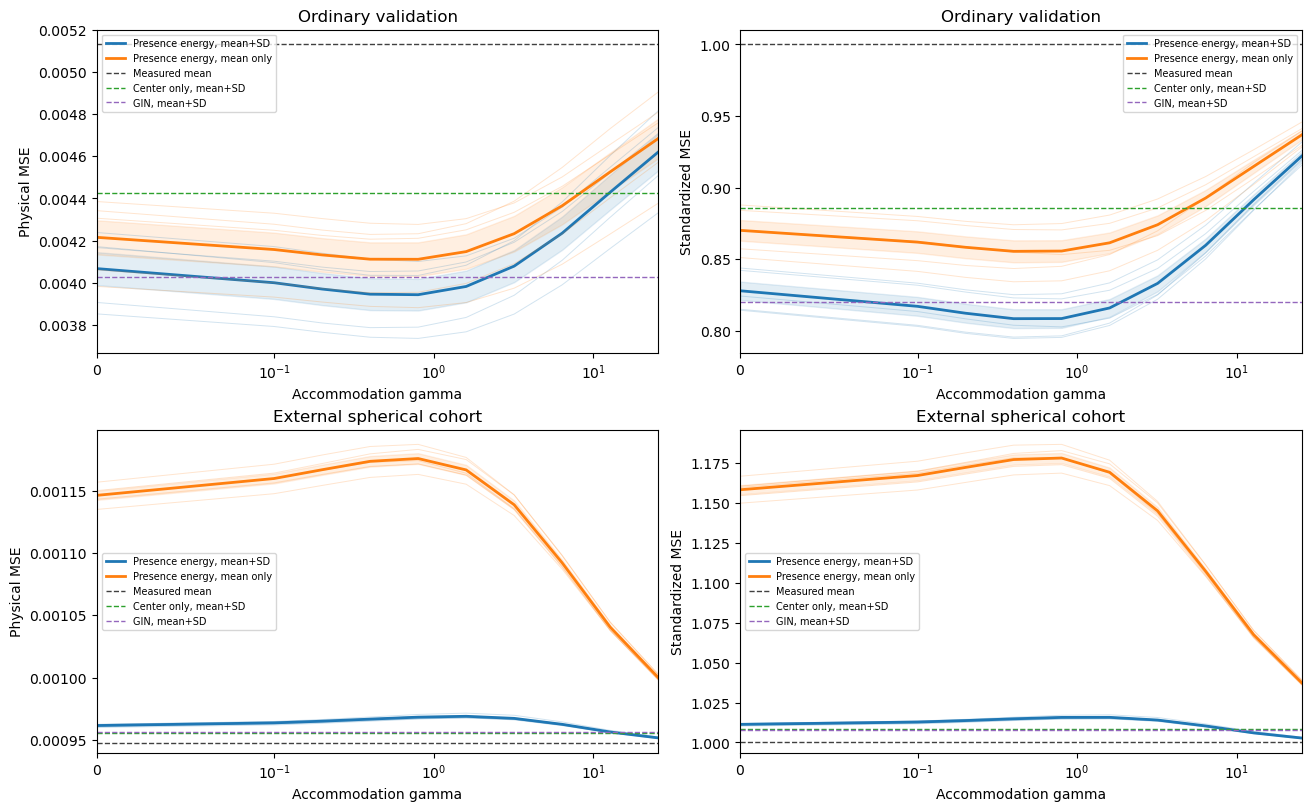

In [5]:
labels={'standardized_center_only':'Center only, mean+SD','standardized_presence_energy':'Presence energy, mean+SD',
    'mean_only_presence_energy':'Presence energy, mean only','standardized_gin':'GIN, mean+SD',
    'Prior presence (fate-only)':'Prior presence, fate-only','Prior presence + measured mean':'Prior presence + measured mean',
    'Measured mean':'Measured mean','Fitted global baseline':'Fitted global baseline'}
colors={'standardized_center_only':'tab:green','standardized_presence_energy':'tab:blue','mean_only_presence_energy':'tab:orange',
    'standardized_gin':'tab:purple','Prior presence (fate-only)':'tab:red','Prior presence + measured mean':'tab:brown',
    'Measured mean':'0.25','Fitted global baseline':'0.65'}

def save_figure(fig,name):
    fig.savefig(OUTPUT_DIR/f'{name}.png',dpi=160,bbox_inches='tight');plt.show()

# Figure 1: same gamma comparisons; observed means/SDs are shared across all conditional models.
sweep=pd.read_csv(run/'validation_mse.csv')
fig,axes=plt.subplots(2,2,figsize=(13,8),layout='constrained')
for row,role in enumerate(['val','spherical']):
    for col,metric in enumerate(['mse','standardized_mse']):
        ax=axes[row,col]
        for mode in ['standardized','mean_only']:
            d=sweep[(sweep.cohort==role)&(sweep.variant=='presence_energy')&(sweep.target_mode==mode)]
            folds=d.groupby(['fold','gamma'])[metric].mean().reset_index();model=f'{mode}_presence_energy';color=colors[model]
            for _,g in folds.groupby('fold'):ax.plot(g.gamma,g[metric],color=color,lw=.7,alpha=FOLD_ALPHA)
            curve=folds.groupby('gamma')[metric].agg(['mean','sem']);x=curve.index.to_numpy()
            ax.plot(x,curve['mean'],color=color,lw=2,label=labels[model]);ax.fill_between(x,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color=color,alpha=.12)
        for model in ['Measured mean','standardized_center_only','standardized_gin']:
            v=fold_scores[(fold_scores.model==model)&(fold_scores.cohort==role)&(fold_scores.region=='total')][metric]
            if len(v):ax.axhline(v.mean(),color=colors[model],ls='--',lw=1,label=labels[model])
        ax.set_xscale('symlog',linthresh=GAMMA_LINTHRESH);ax.set_xlim(min(settings['gamma_grid']),max(settings['gamma_grid']))
        ax.set(xlabel='Accommodation gamma',ylabel='Physical MSE' if metric=='mse' else 'Standardized MSE',title='Ordinary validation' if role=='val' else 'External spherical cohort')
        ax.legend(fontsize=7)
save_figure(fig,'01_accommodation_profiles')



## Figure 2: selected-model prediction quality
Each fold uses its inner-selected gamma. Small points show folds and large points mean ± SEM. Conditional and fate-only models receive different information.

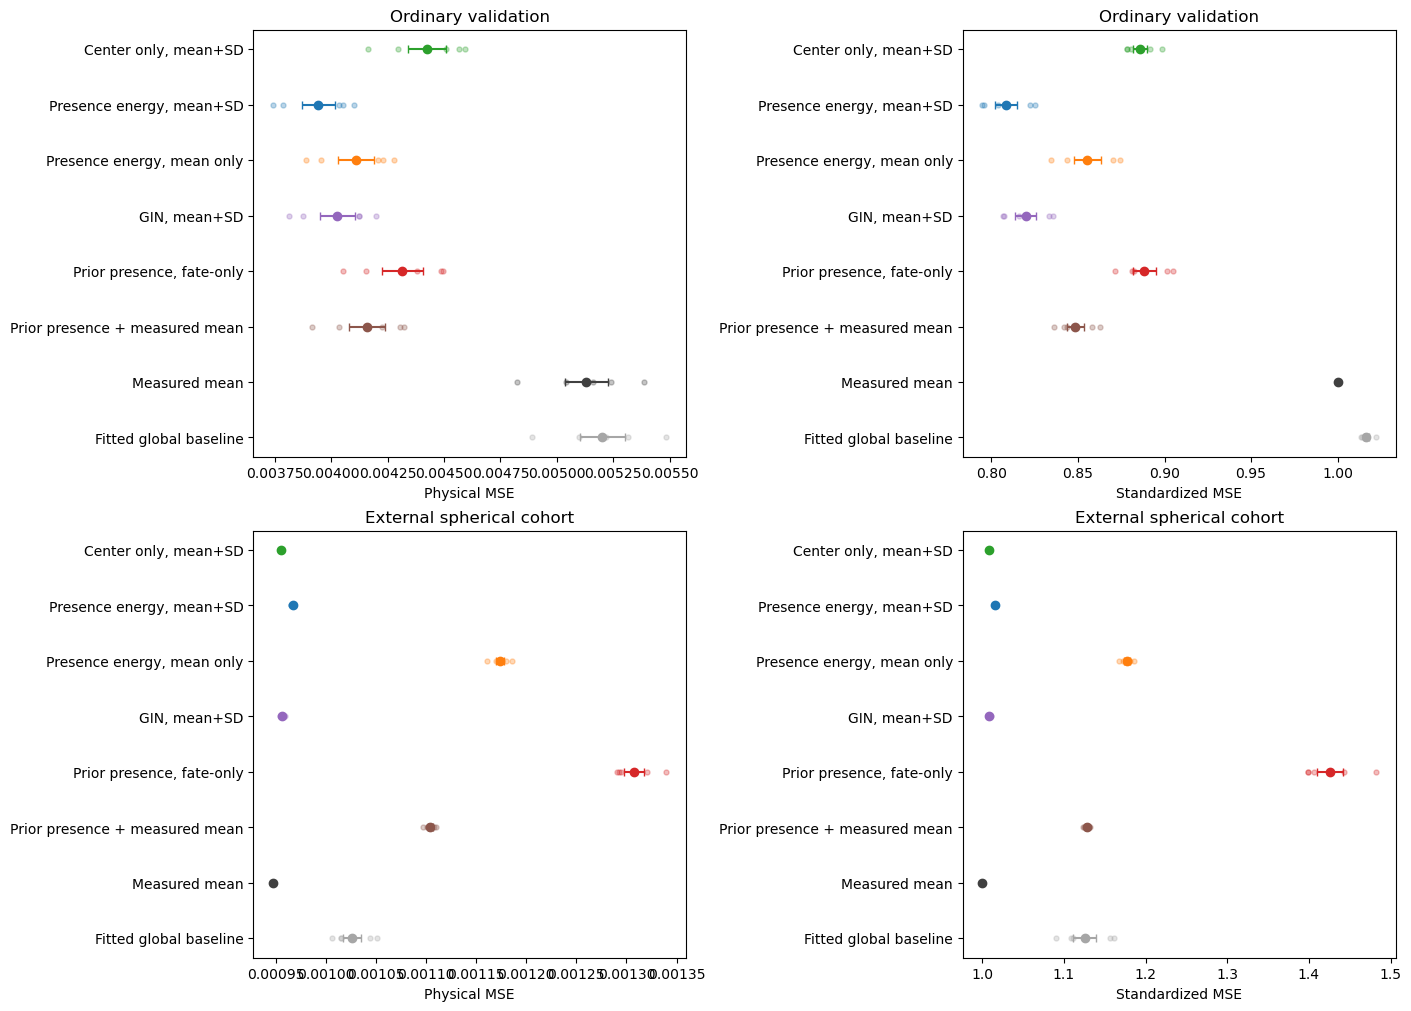

In [6]:
# Figure 2: each fold uses its own inner-selected gamma, never its best outer score.
order=[m for m in labels if m in set(scores.model)]
fig,axes=plt.subplots(2,2,figsize=(14,10),layout='constrained')
for row,role in enumerate(['val','spherical']):
    for col,metric in enumerate(['mse','standardized_mse']):
        ax=axes[row,col]
        for y,model in enumerate(order):
            v=fold_scores[(fold_scores.model==model)&(fold_scores.cohort==role)&(fold_scores.region=='total')][metric].to_numpy()
            ax.scatter(v,np.full(len(v),y),s=13,alpha=.3,color=colors[model])
            ax.errorbar(np.mean(v),y,xerr=pd.Series(v).sem(),fmt='o',color=colors[model],capsize=3)
        ax.set_yticks(range(len(order)),[labels[m] for m in order]);ax.invert_yaxis()
        ax.set(xlabel='Physical MSE' if metric=='mse' else 'Standardized MSE',title='Ordinary validation' if role=='val' else 'External spherical cohort')
save_figure(fig,'02_selected_prediction_quality')



## Figure 3: regional validation
Compare models within identical regional masks for ordinary organoids. External spherical organoids remain separate in Figures 1 and 2.

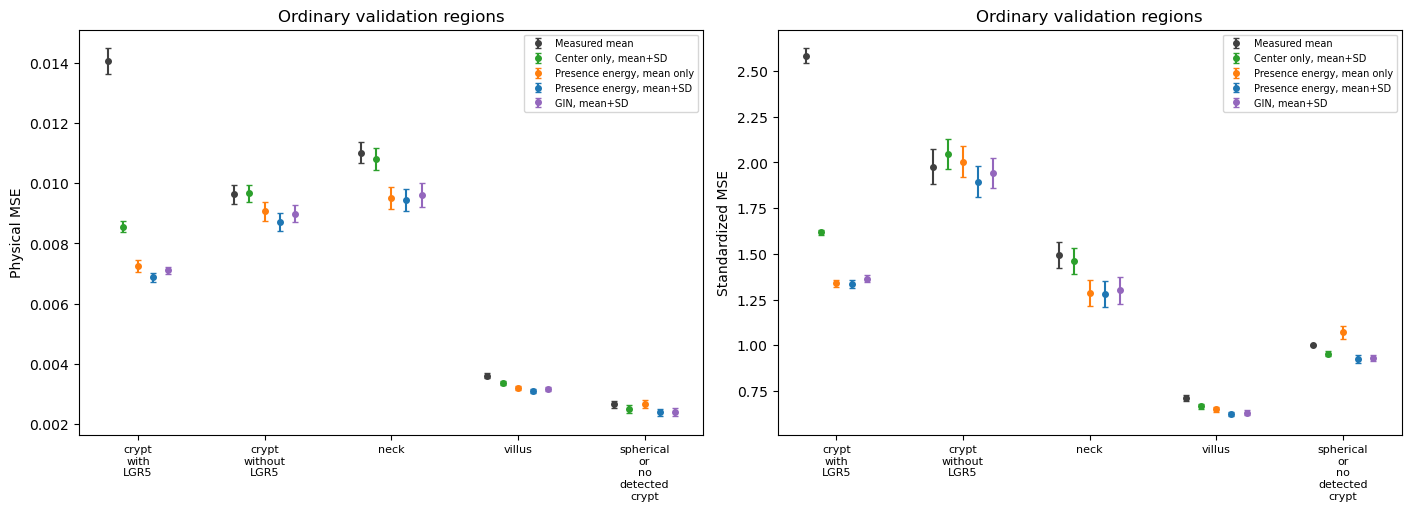

In [7]:
# Figure 3: regions remain evaluation labels only; spherical organoids are kept out of ordinary regional summaries.
region_order=['crypt_with_LGR5','crypt_without_LGR5','neck','villus','spherical_or_no_detected_crypt']
shown=['Measured mean','standardized_center_only','mean_only_presence_energy','standardized_presence_energy','standardized_gin']
fig,axes=plt.subplots(1,2,figsize=(14,5),layout='constrained')
for ax,metric in zip(axes,['mse','standardized_mse']):
    for j,model in enumerate(shown):
        d=fold_scores[(fold_scores.cohort=='val')&(fold_scores.model==model)].groupby('region')[metric].agg(['mean','sem']).reindex(region_order)
        x=np.arange(len(region_order))+(j-2)*.12
        ax.errorbar(x,d['mean'],yerr=d['sem'],fmt='o',ms=4,capsize=2,color=colors[model],label=labels[model])
    ax.set_xticks(range(len(region_order)),[r.replace('_','\n') for r in region_order],fontsize=8)
    ax.set(ylabel='Physical MSE' if metric=='mse' else 'Standardized MSE',title='Ordinary validation regions');ax.legend(fontsize=7)
save_figure(fig,'03_regional_prediction_quality')



## Figure 4: homogeneous LGR5/KI67 neighborhoods
Plot MSE and signed error against one-hop same-identity fraction, weighting organoids equally within bins. Crosses mark sparse support. N-stratified summaries are exported for follow-up.

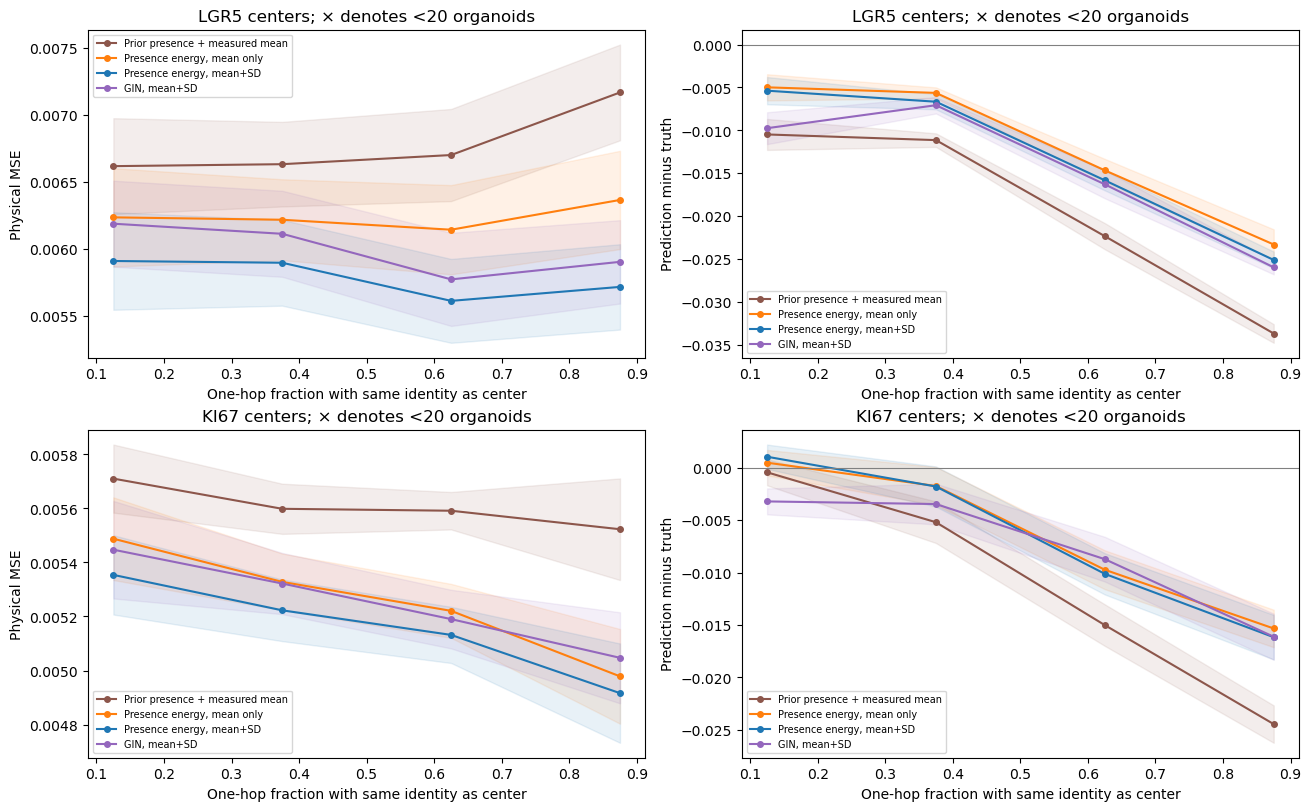

In [8]:
# Figure 4: same-identity fraction within the one-hop ring. Each organoid receives equal weight within a bin.
homo=homogeneity[homogeneity.cohort=='val']
support=homo[homo.model=='standardized_presence_energy'].groupby(['center','bin','midpoint']).agg(organoids=('organoid_str','nunique'),cells=('cells','sum')).reset_index()
support.to_csv(OUTPUT_DIR/'homogeneity_support.csv',index=False)
fig,axes=plt.subplots(2,2,figsize=(13,8),layout='constrained')
for row,center in enumerate(CENTER_MARKERS):
    for col,metric in enumerate(['mse','signed_error']):
        ax=axes[row,col]
        for model in ['Prior presence + measured mean','mean_only_presence_energy','standardized_presence_energy','standardized_gin']:
            d=homo[(homo.center==center)&(homo.model==model)].groupby(['fold','bin','midpoint'])[metric].mean().reset_index()
            curve=d.groupby(['bin','midpoint'])[metric].agg(['mean','sem']).reset_index();x=curve.midpoint.to_numpy()
            ax.plot(x,curve['mean'],'-o',color=colors[model],label=labels[model],ms=4)
            ax.fill_between(x,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color=colors[model],alpha=.1)
            sparse=set(support[(support.center==center)&(support.organoids<MIN_BIN_ORGANOIDS)].bin)
            t=curve[curve.bin.isin(sparse)];ax.scatter(t.midpoint,t['mean'],marker='x',color='black',zorder=5)
        if metric=='signed_error':ax.axhline(0,color='0.5',lw=.8)
        ax.set(xlabel='One-hop fraction with same identity as center',ylabel='Physical MSE' if metric=='mse' else 'Prediction minus truth',title=f'{center} centers; × denotes <{MIN_BIN_ORGANOIDS} organoids')
        ax.legend(fontsize=7)
save_figure(fig,'04_homogeneous_neighborhoods')



## Figure 5: local preference versus accommodation
For neighborhoods with at least 75% same-identity neighbors, compare measured standardized curvature, local preference and accommodated prediction. This is an aggregate diagnostic, not a causal decomposition.

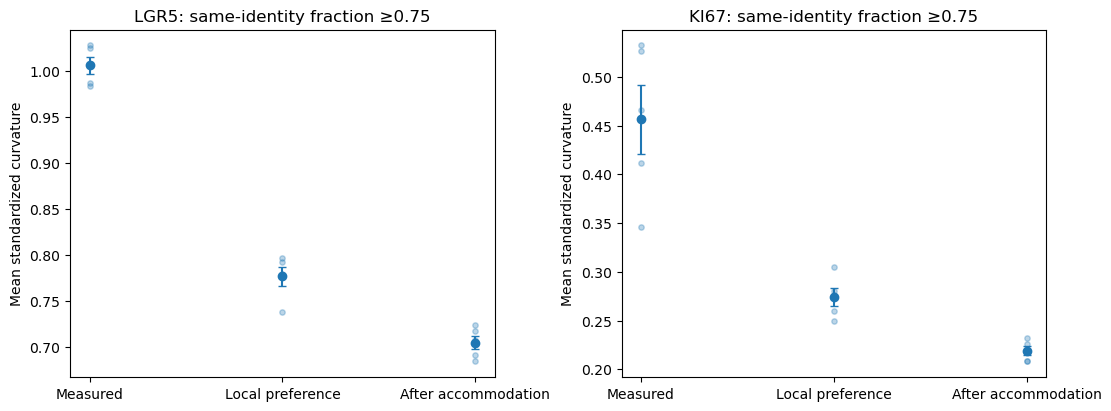

In [9]:
# Figure 5: are the highest-purity predictions set locally, or changed substantially by accommodation?
diagnostic=pd.DataFrame(diagnostic_rows,columns=['fold','cohort','organoid_str','center','cells','true_z','local_z','accommodated_z','accommodation_change']);fig,axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
for ax,center in zip(axes,CENTER_MARKERS):
    d=diagnostic[(diagnostic.center==center)&(diagnostic.cohort=='val')]
    if d.empty:
        ax.text(.5,.5,'No eligible homogeneous neighborhoods',ha='center',transform=ax.transAxes);ax.set_title(center);continue
    for x,column,label in [(0,'true_z','Measured'),(1,'local_z','Local preference'),(2,'accommodated_z','After accommodation')]:
        v=d.groupby('fold')[column].mean()
        ax.scatter(np.full(len(v),x),v,s=15,alpha=.3,color='tab:blue');ax.errorbar(x,v.mean(),yerr=v.sem(),fmt='o',color='tab:blue',capsize=3)
    ax.set_xticks([0,1,2],['Measured','Local preference','After accommodation']);ax.set(ylabel='Mean standardized curvature',title=f'{center}: same-identity fraction ≥0.75')
save_figure(fig,'05_local_and_propagated_fields')



## Figure 6: conditional coefficient stability
At common gamma, show pair means and SD across folds. These are reference-dependent standardized allocation coefficients, not absolute native curvatures or material parameters.

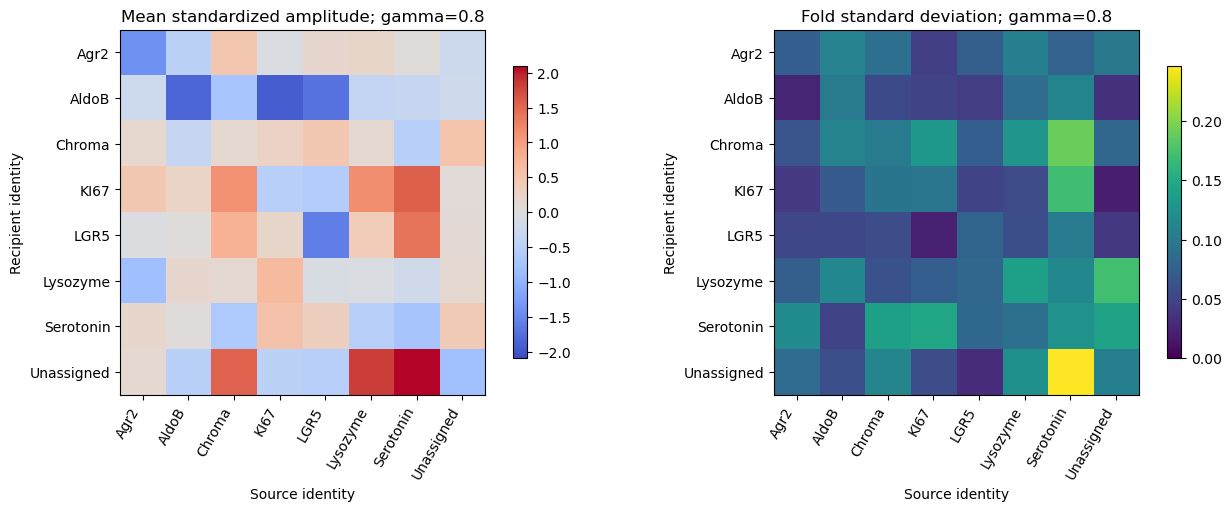

In [10]:
# Figure 6: common-gamma conditional pair amplitudes; absolute center levels are reference dependent.
pairs=coefficients[coefficients.family=='interaction'].copy();stability=pairs.groupby(['recipient','source']).value.agg(['mean','std','count']).reset_index()
sign=pairs.assign(positive=pairs.value>SIGN_TOLERANCE,negative=pairs.value<-SIGN_TOLERANCE).groupby(['recipient','source']).agg(positive=('positive','sum'),negative=('negative','sum')).reset_index()
stability=stability.merge(sign,on=['recipient','source']);stability['unanimous']=(stability.positive==len(membership))|(stability.negative==len(membership))
stability.to_csv(OUTPUT_DIR/'interaction_stability.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(13,5),layout='constrained')
for ax,column,title in zip(axes,['mean','std'],['Mean standardized amplitude','Fold standard deviation']):
    matrix=stability.pivot(index='recipient',columns='source',values=column).reindex(index=identities,columns=identities)
    vmax=float(np.abs(matrix.to_numpy()).max());im=ax.imshow(matrix,cmap='coolwarm' if column=='mean' else 'viridis',vmin=-vmax if column=='mean' else 0,vmax=vmax)
    ax.set_xticks(range(len(identities)),identities,rotation=60,ha='right');ax.set_yticks(range(len(identities)),identities)
    ax.set(xlabel='Source identity',ylabel='Recipient identity',title=f'{title}; gamma={COEFFICIENT_GAMMA:g}');fig.colorbar(im,ax=ax,shrink=.8)
save_figure(fig,'06_conditional_interaction_stability')


## Figure 7: center coefficients of the selected model
Restore the **standardized presence-energy model selected on inner validation in each fold**, matching the viewer and prediction comparisons. These folds use γ=0.8 for fold 0 and γ=0.4 for folds 1–4 in the current run. Small colored points are individual fits; black diamonds are fold means. Unlike Figure 6, this compares the selected models, so dispersion includes differences in accommodation as well as training data.

The local field is `u_i = a_A + sum_B beta_AB * presence(B near i)`, followed by graph-mean removal and accommodation. The plotted center coefficients are the saved regularized values in **standardized curvature units**. Their common offset is not identifiable after mean removal; they are relative allocation coefficients, not isolated-cell physical curvatures. No N dependence is fitted. Physical changes are obtained using each organoid's saved effective SD, so there is no single physical-unit coefficient table for all organoids.

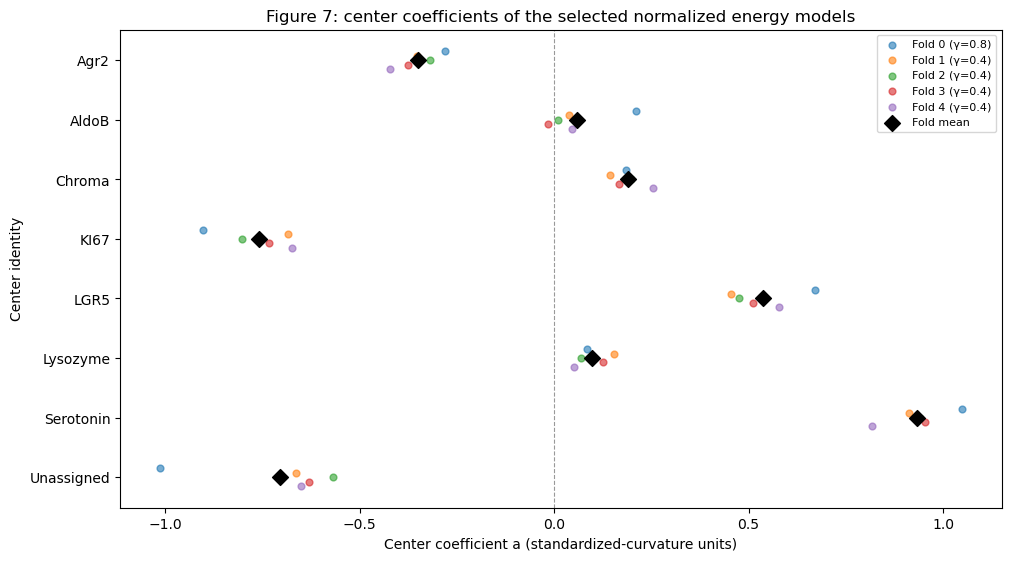

In [4]:
# Use the same fitted models as the selected-prediction figures and organoid viewer.
optimal_selection=selection[selection.target_mode=='standardized'].sort_values('fold')
if set(optimal_selection.fold)!={s['fold'] for s in membership} or optimal_selection.fold.duplicated().any():
    raise ValueError('Expected one inner-selected standardized model per fold.')
optimal_identity_names=load_bundle(run/records[records.key==optimal_selection.iloc[0].key].iloc[0].input_bundle)['marker_names']+['Unassigned']
optimal_rows=[]
for chosen in optimal_selection.itertuples():
    matched=records[records.key==chosen.key]
    if len(matched)!=1:raise ValueError('Ambiguous selected checkpoint.')
    record=matched.iloc[0]
    if record.target_mode!='standardized' or record.variant!='presence_energy' or record.fold!=chosen.fold or float(record.gamma)!=float(chosen.gamma):
        raise ValueError('Selected checkpoint does not match the normalized presence model.')
    fitted=load_bundle(run/record.bundle)['model']
    if not fitted.zero_mean_output or fitted.size_dependent or fitted.activation!='presence' or fitted.fixed_strength!=float(chosen.gamma):
        raise ValueError('Unexpected fitted coefficient parameterization.')
    table=fitted.coefficients([1])  # Constant coefficients: supplied N does not change these values.
    for a,recipient in enumerate(optimal_identity_names):
        optimal_rows.append(dict(fold=int(chosen.fold),gamma=float(chosen.gamma),key=chosen.key,family='center',recipient=recipient,source='',value=float(table['center'][0,a])))
        for b,source in enumerate(optimal_identity_names):
            optimal_rows.append(dict(fold=int(chosen.fold),gamma=float(chosen.gamma),key=chosen.key,family='interaction',recipient=recipient,source=source,value=float(table['amplitude'][0,a,b])))
optimal_coefficients=pd.DataFrame(optimal_rows)
if not np.isfinite(optimal_coefficients.value).all():raise ValueError('Nonfinite coefficient.')
optimal_coefficients.to_csv(OUTPUT_DIR/'selected_model_coefficients.csv',index=False)
optimal_summary=optimal_coefficients.groupby(['family','recipient','source'],dropna=False).value.agg(['mean','std','min','max','count']).reset_index()
optimal_summary.to_csv(OUTPUT_DIR/'selected_model_coefficient_summary.csv',index=False)
optimal_folds=optimal_selection.fold.to_numpy();optimal_colors=plt.get_cmap('tab10')
optimal_offsets=np.linspace(-.15,.15,len(optimal_folds)) if len(optimal_folds)>1 else np.zeros(1)
optimal_labels=[f'Fold {int(row.fold)} (γ={row.gamma:g})' for row in optimal_selection.itertuples()]

fig,ax=plt.subplots(figsize=(10,5.5),layout='constrained')
for index,fold in enumerate(optimal_folds):
    values=optimal_coefficients[(optimal_coefficients.family=='center')&(optimal_coefficients.fold==fold)].set_index('recipient').value.reindex(optimal_identity_names)
    ax.scatter(values,np.arange(len(optimal_identity_names))+optimal_offsets[index],s=24,alpha=.6,color=optimal_colors(index),label=optimal_labels[index])
means=optimal_summary[optimal_summary.family=='center'].set_index('recipient')['mean'].reindex(optimal_identity_names)
ax.scatter(means,np.arange(len(optimal_identity_names)),s=65,marker='D',color='black',label='Fold mean',zorder=5)
ax.axvline(0,color='0.6',lw=.8,ls='--')
ax.set_yticks(range(len(optimal_identity_names)),optimal_identity_names);ax.invert_yaxis()
ax.set(xlabel='Center coefficient a (standardized-curvature units)',ylabel='Center identity',title='Figure 7: center coefficients of the selected normalized energy models')
ax.legend(fontsize=8,loc='best')
fig.savefig(OUTPUT_DIR/'07_selected_center_coefficients.png',dpi=160,bbox_inches='tight');plt.show()


## Figure 8: interaction strengths of the selected model
Each panel identifies the **recipient/center cell**; its y-axis lists the neighboring **source identities**. A coefficient acts once when that source identity is present anywhere at hop 1, regardless of how many such neighbors occur. Positive/negative values increase/decrease the **unprojected local preference**; output centering and accommodation determine the final spatial response.

Colored points and black diamonds show folds and their mean, using identical axes across recipients. These are conditional fitted associations, not causal signaling strengths. In particular, the all-to-all zero-exposure reference is not an observed source-free neighborhood. The full values and fold summaries are exported as CSV files beside the figures. No model is retrained.

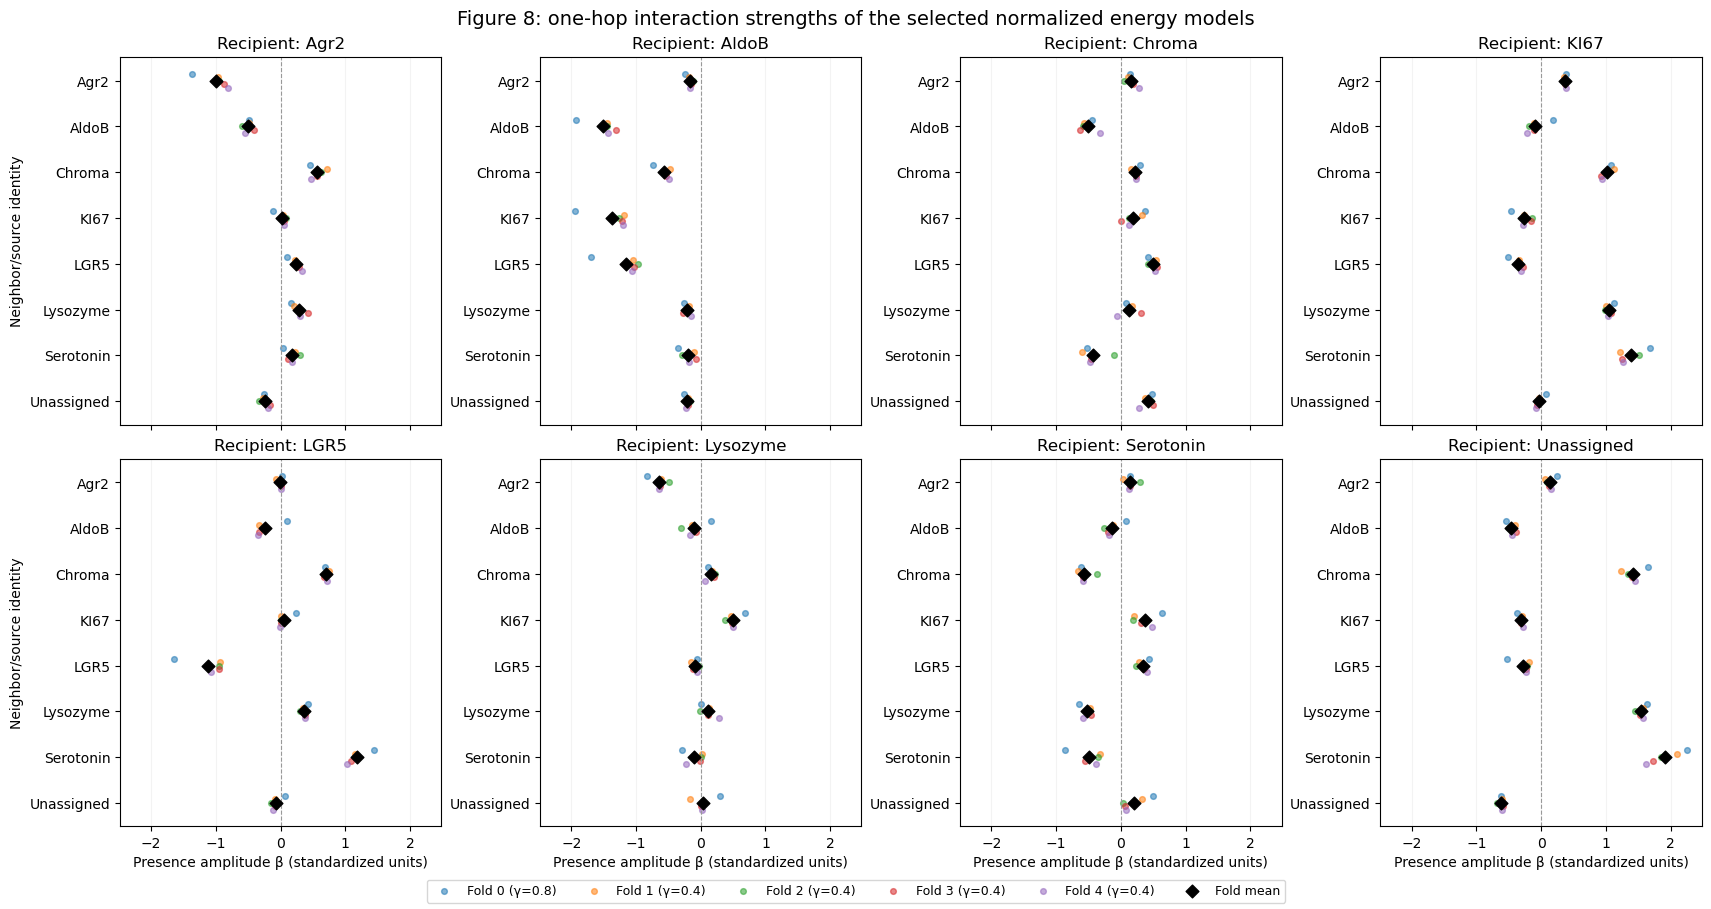

In [5]:
# One panel per recipient; the source acts through literal presence in its one-hop neighborhood.
fig,axes=plt.subplots(2,4,figsize=(17,9),sharex=True,sharey=True,layout='constrained')
interaction_values=optimal_coefficients[optimal_coefficients.family=='interaction']
limit=max(float(interaction_values.value.abs().max())*1.1,1e-6)
for ax,recipient in zip(axes.flat,optimal_identity_names):
    for index,fold in enumerate(optimal_folds):
        values=interaction_values[(interaction_values.recipient==recipient)&(interaction_values.fold==fold)].set_index('source').value.reindex(optimal_identity_names)
        ax.scatter(values,np.arange(len(optimal_identity_names))+optimal_offsets[index],s=17,alpha=.55,color=optimal_colors(index),label=optimal_labels[index])
    means=optimal_summary[(optimal_summary.family=='interaction')&(optimal_summary.recipient==recipient)].set_index('source')['mean'].reindex(optimal_identity_names)
    ax.scatter(means,np.arange(len(optimal_identity_names)),s=42,marker='D',color='black',label='Fold mean',zorder=5)
    ax.axvline(0,color='0.6',lw=.8,ls='--');ax.set_xlim(-limit,limit)
    ax.set_yticks(range(len(optimal_identity_names)),optimal_identity_names);ax.tick_params(labelleft=True)
    ax.set_title(f'Recipient: {recipient}');ax.grid(axis='x',alpha=.15)
axes[0,0].invert_yaxis()
for ax in axes[-1]:ax.set_xlabel('Presence amplitude β (standardized units)')
for ax in axes[:,0]:ax.set_ylabel('Neighbor/source identity')
handles,legend_labels=axes[0,0].get_legend_handles_labels()
fig.legend(handles,legend_labels,loc='outside lower center',ncol=min(len(legend_labels),6),fontsize=9)
fig.suptitle('Figure 8: one-hop interaction strengths of the selected normalized energy models',fontsize=14)
fig.savefig(OUTPUT_DIR/'08_selected_interaction_strengths.png',dpi=160,bbox_inches='tight');plt.show()


## Findings and saved report
Summarize held-out comparisons and homogeneous-neighborhood errors. Record the future artificial-graph experiment, including the distinction between mean-projection offsets and mechanical propagation.

In [6]:
def markdown_table(frame):
    lines=['| '+' | '.join(map(str,frame.columns))+' |','| '+' | '.join(['---']*len(frame.columns))+' |']
    for row in frame.itertuples(index=False,name=None):lines.append('| '+' | '.join(f'{v:.6g}' if isinstance(v,(float,np.floating)) else str(v) for v in row)+' |')
    return '\n'.join(lines)

main=summary[summary.region=='total'].copy()
ordinary=main[main.cohort=='val'].set_index('model');spherical=main[main.cohort=='spherical'].set_index('model')
comparisons=[]
for first,second in [('standardized_presence_energy','Measured mean'),('standardized_presence_energy','mean_only_presence_energy'),
    ('standardized_presence_energy','standardized_center_only'),('standardized_presence_energy','Prior presence + measured mean'),
    ('standardized_gin','standardized_presence_energy')]:
    if first not in set(scores.model) or second not in set(scores.model):continue
    for role in ['val','spherical']:
        d=scores[(scores.region=='total')&(scores.cohort==role)&scores.model.isin([first,second])]
        p=d.pivot(index=['fold','organoid_str'],columns='model',values='mse');delta=(p[first]-p[second]).groupby('fold').mean()
        comparisons.append(dict(cohort=role,contrast=f'{first} - {second}',mean_difference=delta.mean(),fold_sem=delta.sem(),negative_folds=int((delta<0).sum()),folds=len(delta)))
paired=pd.DataFrame(comparisons);paired.to_csv(OUTPUT_DIR/'paired_mse_comparisons.csv',index=False)
high=homogeneity[(homogeneity.cohort=='val')&(homogeneity.bin==len(HOMOGENEITY_EDGES)-2)]
high_summary=high.groupby(['model','center','fold']).agg(mse=('mse','mean'),signed_error=('signed_error','mean')).groupby(['model','center']).mean().reset_index()
high_summary.to_csv(OUTPUT_DIR/'high_homogeneity_summary.csv',index=False)
N_summary=homogeneity[(homogeneity.cohort=='val')&homogeneity.model.isin(['standardized_presence_energy','mean_only_presence_energy','standardized_gin'])].groupby(['model','center','bin','N_bin','fold']).agg(mse=('mse','mean'),organoids=('organoid_str','nunique')).reset_index()
N_summary.to_csv(OUTPUT_DIR/'homogeneity_by_N.csv',index=False)
floors=pd.read_csv(run/'normalization_floors.csv');moments=pd.read_csv(run/'observed_moments.csv')
finite_scores=np.isfinite(scores[['mse','standardized_mse','signed_error']].to_numpy()).all()
assert finite_scores
relative_gain=100*(1-ordinary.loc['standardized_presence_energy','mse']/ordinary.loc['Measured mean','mse'])
scale_change=100*(ordinary.loc['standardized_presence_energy','mse']/ordinary.loc['mean_only_presence_energy','mse']-1)
lines=['# Conditional curvature allocation from exclusive fates','',
    f'Run: `{run.name}`. {len(membership)} exact saved folds, {int((cohort_table.cohort=="ordinary").sum())} ordinary organoids, {int((cohort_table.cohort=="spherical").sum())} external spherical organoids. All {len(records)} checkpoints restored and checked against saved predictions.','',
    '## Main findings','',
    f'The mean-and-SD energy model achieves ordinary physical MSE {ordinary.loc["standardized_presence_energy","mse"]:.7f}, a {relative_gain:.1f}% reduction from predicting the measured organoid mean everywhere. Its mean within-organoid R² is {ordinary.loc["standardized_presence_energy","within_r2"]:.3f}; this averages each organoid separately and differs from a ratio of pooled MSEs.','',
    f'Against the otherwise matched mean-subtraction-only energy model, physical MSE changes by {scale_change:+.1f}%. Standardized MSE is {ordinary.loc["standardized_presence_energy","standardized_mse"]:.4f} versus {ordinary.loc["mean_only_presence_energy","standardized_mse"]:.4f}. These objectives weight curvature variation differently; the physical and standardized rankings need not agree.','',
    markdown_table(main[['model','cohort','mse','mse_sem','standardized_mse','within_r2','spearman','predicted_sd_ratio']]),'',
    '## What was fitted','',
    'For each graph, z_i=(H_i-m_g)/s_eff,g, with population mean m_g and SD s_g computed from the original training-fitted, cleaned physical target. s_eff=max(s_g, floor). Reconstruction is Hhat=m_g+s_eff*zhat. The mean-only control uses H-m_g and restores m_g without scaling. Averages use equal cells within each organoid; MSE gives each organoid equal weight, then averages folds equally. There are no approximate cell-area weights.','',
    'The explicit field is zhat=(I+gamma*L)^(-1)*(u-mean(u)); u contains center identity and all-to-all one-hop presence coefficients. Constant gamma is profiled on the same ten-value grid. Shrinkage and gamma selection use only the inner training holdout. All outer/spherical metrics are evaluated afterward. There is no N-dependent local parameter, learned activation, or measured-neighbor curvature input.','',
    'The added zero_mean_output option defaults to False, preserving historical energy models. It centers the design matrix consistently in CPU and CUDA fitting/inference. For the GIN, the differentiable output projection is applied in both training and inference; accumulation uses float64 before restoring the output dtype. A projected model has an arbitrary common center-coefficient level; ridge fixes a numerical convention, not an absolute native curvature.','',
    'The plain GIN has one message-passing layer, 128 hidden units, no FiLM/global inputs, and identical outer/inner membership. Its inner-selected epoch count is followed by reinitialization and refitting all ordinary-training organoids. Existing global baselines are retained as references, not subtracted from the conditional targets.','',
    '## Honest use of measured summaries','',
    'Every held-out organoid intentionally supplies its own measured mean and SD. This is label-assisted conditional reconstruction, not independent prediction of shape from fate. Inference of the standardized field was verified with cell-level targets removed from model inputs. Observed summaries are stored separately and used for inversion only. Global shape/history has not been causally isolated by conditioning on these summaries.','',
    f'SD floors range from {floors.std_floor.min():.6g} to {floors.std_floor.max():.6g}, using only inner-training organoids. Floored ordinary validation instances: {int(moments[moments.cohort=="val"].floor_applied.sum())}; spherical instances: {int(moments[moments.cohort=="spherical"].floor_applied.sum())} across all folds (the spherical cohort is repeated).','',
    'Predicted variance is not forced to match observed variance: predicted_SD/true_SD quantifies under-allocation. The external spherical cohort never selects parameters. Five folds share training organoids, so SEM and sign agreement are descriptive, not independent-replicate confidence estimates.','',
    '## Paired model comparisons','',markdown_table(paired),'',
    'The old fate-only model receives less information and is a contextual reference, not a fair predictive contest. Replacing only its predicted graph mean by the measured mean isolates the immediate benefit of knowing that mean. The newly fitted mean-only versus mean-and-SD models isolate the further effect of rescaled fitting, with the same output projection and fitting protocol.','',
    '## Homogeneous neighborhoods','',
    'One-hop purity is the fraction of neighbors with the same identity as the center. The highest bin is [0.75,1]. Comparisons use the same cells and average within organoid before averaging folds. Sparse bins are marked in Figure 4; N-stratified summaries are exported separately. Neither N nor region labels select models.','',
    markdown_table(high_summary[high_summary.model.isin(['Prior presence + measured mean','mean_only_presence_energy','standardized_presence_energy','standardized_gin'])]),'',
    '## Conditional coefficient stability','',
    f'At common gamma={COEFFICIENT_GAMMA:g}, {int(stability.unanimous.sum())}/{len(stability)} pair coefficients have unanimous non-negligible signs across folds, using tolerance {SIGN_TOLERANCE:g} standardized units. This is not a significance test. Binary presence/absence support alone does not identify a mechanism. These are conditional standardized allocation coefficients, not old physical-curvature coefficients or independently measured material parameters.','',
    '## Figures in the evaluation notebook','',
    '1. `01_accommodation_profiles.png`: physical and standardized MSE against gamma; ordinary and spherical cohorts.',
    '2. `02_selected_prediction_quality.png`: inner-selected models and baseline references; fold points and mean ± SEM.',
    '3. `03_regional_prediction_quality.png`: regional errors; region labels do not enter prediction.',
    '4. `04_homogeneous_neighborhoods.png`: MSE and signed error versus same-identity fraction around LGR5/KI67.',
    '5. `05_local_and_propagated_fields.png`: measured field, local preference and accommodation in homogeneous neighborhoods.',
    '6. `06_conditional_interaction_stability.png`: mean amplitudes and fold SD at a common gamma.',
    '7. `07_selected_center_coefficients.png`: center coefficients for each inner-selected fold model and their mean.',
    '8. `08_selected_interaction_strengths.png`: corresponding one-hop presence amplitudes, one panel per recipient. These selected models may have different gamma; the mean is a parameter summary, not an averaged predictor.','',
    '## Planned next experiment: artificial lineage neighborhoods','',
    'Recorded user request, not executed here: construct artificial graphs with LGR5-rich and KI67-rich backgrounds, introduce secretory identities individually, and measure field changes versus graph distance. Keep the graph and externally chosen mean/SD fixed when changing fate; start with standardized responses, because artificial graphs have no measured curvature moments. Vary source number, spacing and background composition.','',
    'Separate the change in unprojected local preference, its mechanically accommodated field, and the zero-mean projected field. Output centering creates a uniform compensating shift after a local perturbation, even at gamma=0; do not mistake that shift for long-range mechanical propagation. Test graph size/boundary sensitivity and compare folds at common gamma. These are model diagnostics, not evidence of causal secretory signaling.','']
extra=['## Interpretation of this run','']
if 'standardized_gin' in ordinary.index:
    ratio=100*(1-ordinary.loc['standardized_presence_energy','mse']/ordinary.loc['standardized_gin','mse'])
    extra += [f'The normalized energy model has {ratio:.1f}% lower ordinary physical MSE than the particular depth-1 GIN benchmark trained here. Both use the same summaries; this is not a claim against optimized or deeper GNNs. The energy model accommodates across the full graph, whereas the GIN has one message-passing layer (both additionally have graph-mean output projection).','']
extra += [f'Center identity alone explains {100*ordinary.loc["standardized_center_only","within_r2"]:.1f}% of within-organoid variance on average; adding presence interactions and accommodation explains {100*ordinary.loc["standardized_presence_energy","within_r2"]:.1f}%. This gain concerns the combined neighborhood/propagation model and does not establish causal pairwise effects.','']
for center in CENTER_MARKERS:
    h=high_summary[high_summary.center==center].set_index('model')
    if {'standardized_presence_energy','mean_only_presence_energy'}<=set(h.index):
        gain=100*(1-h.loc['standardized_presence_energy','mse']/h.loc['mean_only_presence_energy','mse'])
        error=h.loc['standardized_presence_energy','signed_error']
        extra += [f'For {center} centers with at least 75% same-identity neighbors, normalized fitting reduces physical MSE by {gain:.1f}% relative to mean-only fitting. Mean prediction-minus-truth is {error:+.5f}: lower MSE has not eliminated systematic bias.','']
sphere_excess=100*(spherical.loc['standardized_presence_energy','mse']/spherical.loc['Measured mean','mse']-1)
extra += [f'On spherical organoids, normalized energy predictions have {sphere_excess:.1f}% higher physical MSE than the measured-mean predictor. Thus the ordinary-cohort allocation pattern does not generalize into useful added spatial prediction for this cohort on average. Supplying the global spread prevents much of the older over-allocation, but does not establish that the local fate pattern correctly locates its remaining curvature variation.','',
    'The result supports using measured-summary normalization as a diagnostic of conditional allocation. It does not recover developmental history, identify native-cell mechanical parameters, or show that an interaction coefficient measures biochemical signaling. A constant coefficient in standardized units corresponds to a physical-unit response scaled by the supplied organoid SD.','']
lines[4:4]=extra
(run/'REPORT.md').write_text('\n'.join(lines))
(OUTPUT_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),folds=len(membership),restoration_max_error=max(v['max_difference'] for v in verification),finite_scores=bool(finite_scores),conditional_reconstruction=True),indent=2))
display(summary[(summary.region=='total')&(summary.cohort=='val')][['model','mse','standardized_mse','within_r2','spearman']])
print('Report:',run/'REPORT.md')


,model,mse,standardized_mse,within_r2,spearman
6,Fitted global baseline,0.005202,1.016489,-1.648872e-02,NaN
14,Measured mean,0.005131,1.000000,-2.222659e-17,NaN
22,Prior presence (fate-only),0.004315,0.888331,1.116687e-01,0.405694
30,Prior presence + measured mean,0.004160,0.848530,1.514701e-01,0.405694
38,mean_only_presence_energy,0.004110,0.855479,1.445214e-01,0.403070
46,standardized_center_only,0.004425,0.885639,1.143611e-01,0.281986
54,standardized_gin,0.004027,0.819816,1.801839e-01,0.345509
62,standardized_presence_energy,0.003943,0.808391,1.916090e-01,0.405248


Report: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/shape_conditioned_energy_training/observed_mean_std_presence_20261002_144511/REPORT.md
